In [1]:
%load_ext autoreload

%autoreload 2

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import seaborn as sns   
import os
from pathlib import Path
import seaborn as sns
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts
from statsmodels.distributions.empirical_distribution import ECDF
from math import ceil
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from scipy.stats import ks_2samp
from scipy import stats
from scipy.stats import norm
import warnings
from preproces_prod4_2025_update import *
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from matching_case_control import match_nn_max_dist_weigths
import numpy as np

warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [ ]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr
df_cox_vrs_mrz_ag = pd.read_csv(path_data/'df_cox_vrs_mrz_ag.csv')
df_f_vrs_mrz_ag = pd.read_csv(path_data/'df_f_vrs_mrz_ag.csv')
df_cox_vrs_24 = pd.read_csv(path_data/'df_cox_vrs_24.csv')
df_f_vrs_24 = pd.read_csv(path_data/'df_f_vrs_24.csv')

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025


In [17]:
inmu_24 = df_f_vrs_24.inmunizado.value_counts().values[0] 
no_inmu_24 = df_f_vrs_24.inmunizado.value_counts().values[1] 

inmu_24/no_inmu_24

17.056170513424398

In [29]:
inmu = df_f_vrs_mrz_ag.inmunizado.value_counts().values[0] 
no_inmu = df_f_vrs_mrz_ag.inmunizado.value_counts().values[1] 

inmu/no_inmu

36.2969205834684

In [ ]:
r = inmu_24/no_inmu_24
inmu = df_cox_vrs_mrz_ag.groupby('RUN').inmunizado.max().value_counts().values[0] 
no_inmu = df_cox_vrs_mrz_ag.inmunizado.value_counts().values[1] 

n_inmunes_por_crear = int((inmu - r*no_inmu)/r)

n_inmunes_por_crear

3480

In [ ]:
################################################################ peso de añadir los que faltan 

df = df_cox_vrs_mrz_ag.copy()

ID_COL = "RUN"
START, STOP = "start", "stop"
IMM = "inmunizado"  # 0/1 por fila time-varying

# Definir "no inmune" como: individuos que NUNCA están inmunizados (max==0)
ever = df.groupby(ID_COL)[IMM].max()
no_ids = ever[ever == 0].index

n0 = len(no_ids)
target_extra = 3480
target_total = n0 + target_extra

# Peso multiplicativo para que el total "equivalente" de no-inmunes sea target_total
w0 = target_total / n0

df["w_ipw_sim"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ipw_sim"] = w0

print("No-inmunes reales:", n0)
print("Peso no-inmune:", w0)
print("No-inmunes equivalentes (suma pesos):", df.loc[df[ID_COL].isin(no_ids), "w_ipw_sim"].sum())


covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac','w_ipw_sim']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata, weights_col="w_ipw_sim",)
display(printSummary(ctv_0))


No-inmunes reales: 3085
Peso no-inmune: 2.1280388978930307
No-inmunes equivalentes (suma pesos): 6565.0


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.287065,0.723920,0.086013,-1.455646,-1.118483,0.673225,0.766750,0.0
sexo,0.509718,-0.664821,0.057950,0.396137,0.623298,-0.865069,-0.486073,0.0


In [ ]:
################################################################ peso de igual ratio (más exacto que arriba, no aproxima el ratio)

vc = df_f_vrs_24["inmunizado"].value_counts()
inmu_24    = vc.get(1, 0)
no_inmu_24 = vc.get(0, 0)

r = inmu_24 / no_inmu_24
print("inmu_24:", inmu_24, "| no_inmu_24:", no_inmu_24, "| r:", r)

# =========================
# 1) Construir pesos en tu base time-varying (full cohort)
# =========================
df = df_cox_vrs_mrz_ag.copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

# "No inmune puro" = individuo que nunca se inmuniza en todo su follow-up
ever_imm = df.groupby(ID_COL)[IMM_COL].max()
no_ids = ever_imm[ever_imm == 0].index

n_imm = (ever_imm == 1).sum()
n_no  = (ever_imm == 0).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)

# Queremos que el ratio quede EXACTAMENTE r:
# ratio_final = n_imm / (w0 * n_no) = r  =>  w0 = n_imm / (r * n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()

covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata, weights_col="w_ratio")
display(printSummary(ctv_0))


inmu_24: 144841 | no_inmu_24: 8492 | r: 17.056170513424398
Full cohort (ever_imm): inmunes = 111976 | no_inmunes = 3085 | ratio actual = 36.2969205834684
Peso aplicado a no-inmunes (w0): 2.128081479655717
No-inmunes equivalentes (suma pesos a nivel de filas NO es el n; el objetivo es el ratio en el likelihood)


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.287068,0.723921,0.086012,-1.455648,-1.118488,0.673226,0.766751,0.0
sexo,0.509717,-0.664821,0.057950,0.396137,0.623297,-0.865068,-0.486073,0.0


In [ ]:
############################################################### Vemos hipotesis marcel: aumentamos peso no inmune.

lista_ratios= [2,7,12,17,22,27,33]

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

# resultados_by_ratio = []

for r in lista_ratios:
    print('Ratio', r)
    df = df_cox_vrs_mrz_ag.copy()

    ever_imm = df.groupby(ID_COL)[IMM_COL].max()
    no_ids = ever_imm[ever_imm == 0].index

    n_imm = (ever_imm == 1).sum()
    n_no  = (ever_imm == 0).sum()

    w0 = n_imm / (r * n_no)

    df["w_ratio"] = 1.0
    df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

    print("Peso aplicado a no-inmunes (w0):", w0)
    
    ctv = CoxTimeVaryingFitter()

    covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac','w_ratio']
    df_cox = df.copy()
    ctv = CoxTimeVaryingFitter()
    strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
    ctv.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata, weights_col="w_ratio",)
    
    summ = printSummary(ctv) 
    ve   = float(summ.effectiveness.loc["inmunizado"])
    lo   = float(summ.eff_lower_95.loc["inmunizado"])
    hi   = float(summ.eff_upper_95.loc["inmunizado"])
    resultados_by_ratio.append({"ratio": r,'peso': w0, "VE": ve, "VE_lo95": lo, "VE_hi95": hi})
    
# df_ignasi_ratios = pd.DataFrame(resultados_by_ratio)

Ratio 2
Peso aplicado a no-inmunes (w0): 18.1484602917342
Ratio 7
Peso aplicado a no-inmunes (w0): 5.185274369066914
Ratio 12
Peso aplicado a no-inmunes (w0): 3.0247433819556995
Ratio 17
Peso aplicado a no-inmunes (w0): 2.135112975498141
Ratio 22
Peso aplicado a no-inmunes (w0): 1.6498600265212906
Ratio 27
Peso aplicado a no-inmunes (w0): 1.344330391980311
Ratio 33
Peso aplicado a no-inmunes (w0): 1.0999066843475271


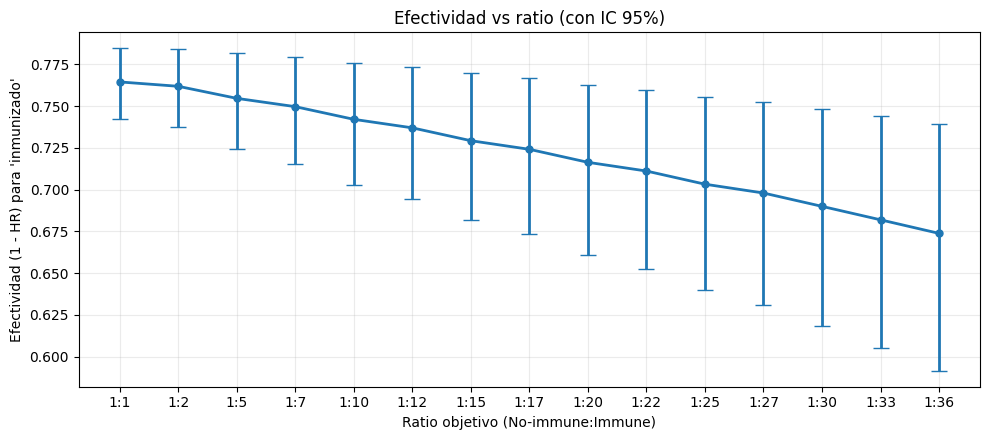

In [ ]:
############################################################### grafico marcel

dfp = df_ignasi_ratios.dropna(subset=["ratio","VE","VE_lo95","VE_hi95"]).copy()
dfp = dfp.sort_values("ratio",ascending=True)

x = np.arange(len(dfp))  # posiciones 0..k-1 para poder etiquetar "1:r"
y = dfp["VE"].to_numpy()
ylo = dfp["VE_lo95"].to_numpy()
yhi = dfp["VE_hi95"].to_numpy()
yerr = np.vstack([y - ylo, yhi - y])

labels = [f"1:{int(r)}" for r in dfp["ratio"].to_list()]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, linewidth=2, markersize=5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)

ax.set_xlabel("Ratio objetivo (No-immune:Immune)")
ax.set_ylabel("Efectividad (1 - HR) para 'inmunizado'")
ax.set_title("Efectividad vs ratio (con IC 95%)")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:

# ==========
# INPUTS
# ==========
df_base = df_f_vrs_mrz_ag.copy()   # 1 fila por RUN
ID_COL = "RUN"

# Treatment a ponderar: ever_imm (1 si se inmunizó alguna vez)
# Si no lo tienes, puedes usar inmunizado como proxy (si significa "tiene fechaInm")
TREAT_COL = "ever_imm"  # <-- AJUSTA si se llama distinto
if TREAT_COL not in df_base.columns:
    # fallback común
    TREAT_COL = "inmunizado"

ps_covs_num = ["SEMANAS",'semana_nac']                 # numéricas
ps_covs_cat = ["mes_nac_name","region"]  # categóricas (ajusta a tus nombres reales)

# ==========
# 1) Matriz X (one-hot para categóricas)
# ==========
X_num = df_base[ps_covs_num].copy()
X_cat_raw = df_base[ps_covs_cat].astype(str).copy()

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = enc.fit_transform(X_cat_raw)
cat_cols = enc.get_feature_names_out(ps_covs_cat)

X_cat = pd.DataFrame(X_cat, columns=cat_cols, index=df_base.index)

X = pd.concat([X_num, X_cat], axis=1).fillna(0)

y = df_base[TREAT_COL].astype(int).values

# ==========
# 2) Logistic regression para PS
# ==========
ps_model = LogisticRegression(max_iter=2000, n_jobs=-1, solver="lbfgs")
ps_model.fit(X, y)

ps = ps_model.predict_proba(X)[:, 1]
ps = np.clip(ps, 1e-6, 1 - 1e-6)  # evita pesos infinitos

df_ps = df_base[[ID_COL]].copy()
df_ps["ps"] = ps
df_ps[TREAT_COL] = y

# ==========
# 3) IPTW estabilizado
# ==========
p_t = y.mean()         # P(T=1)
p_c = 1 - p_t

df_ps["w_iptw"] = np.where(
    df_ps[TREAT_COL] == 1,
    p_t / df_ps["ps"],
    p_c / (1 - df_ps["ps"])
)

# (Opcional) truncar pesos extremos para estabilidad (muy recomendado)
# ej: truncar al p99
cap = df_ps["w_iptw"].quantile(0.99)
df_ps["w_iptw_trunc"] = df_ps["w_iptw"].clip(upper=cap)

from lifelines import CoxTimeVaryingFitter

df_tv = df_cox_vrs_mrz_ag.copy()
df_tv["RUN"] = df_tv["RUN"].astype(str)
df_ps["RUN"] = df_ps["RUN"].astype(str)

# elige qué peso usar (truncado recomendado)
W_COL = "w_iptw_trunc"   # o "w_iptw"

df_tv_w = df_tv.merge(df_ps[["RUN", W_COL]], on="RUN", how="left")

covs = ['start','inmunizado','stop','RUN','sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac', W_COL]
strata = ['region','mes_nac_name','SEMANAS','semana_nac']

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_w[covs],
    id_col="RUN",
    event_col="event_vrs",
    start_col="start",
    stop_col="stop",
    strata=strata,
    weights_col=W_COL
)
display(printSummary(ctv))



PS summary:
count    115061.000000
mean          0.973184
std           0.022083
min           0.782510
25%           0.966445
50%           0.979017
75%           0.989090
max           0.996731
Name: ps, dtype: float64

IPTW summary:
count    115061.000000
mean          0.999657
std           0.125437
min           0.126629
50%           0.993643
90%           1.029230
95%           1.049638
99%           1.145335
max           5.742182
Name: w_iptw, dtype: float64

Cap (p99): 1.1453349418089076


In [ ]:
####################################################################### MONTE CARLO: SAMPLEAMOS SUBCONJUNTO INMUNE (distinto método que peso, menos robusto)


df_tv = df_cox_vrs_mrz_ag.copy()     # time-varying (muchas filas por RUN)

ID_COL    = "RUN"
IMM_COL   = "inmunizado"            # time-varying 0/1 por fila
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
strata = ['region','mes_nac_name','SEMANAS','semana_nac']

lista_ratios = [2,10,20,36]

# Adaptativo:
B0     = 10       # réplicas iniciales por ratio
eps    = 0.002     # tolerancia: SE(mean(VE)) <= eps (ej 0.2 puntos porcentuales)
MAX_B  = 10       # tope duro por ratio (por si acaso)
SEED   = 123

# ============================================================
# 0) IDs "ever_imm" (a nivel individuo)
# ============================================================
ever_imm = df_tv.groupby(ID_COL)[IMM_COL].max()

no_ids  = ever_imm[ever_imm == 0].index.to_numpy()
imm_ids = ever_imm[ever_imm == 1].index.to_numpy()

N0 = len(no_ids)
N1 = len(imm_ids)

print("N no-inmunes (ever_imm=0):", N0)
print("N inmunes    (ever_imm=1):", N1)
print("Ratio natural N1/N0:", (N1 / N0) if N0 else np.nan)

# ============================================================
# Helpers
# ============================================================
def fit_one_rep(df_sub):
    """
    Ajusta CoxTimeVaryingFitter y devuelve VE + IC 95% desde tu printSummary(ctv).
    Si falla converge, devuelve NaNs.
    """
    try:
        ctv = CoxTimeVaryingFitter()
        ctv.fit(
            df_sub[covs],
            id_col=ID_COL,
            event_col=EVENT_COL,
            start_col=START_COL,
            stop_col=STOP_COL,
            strata=strata
        )

        summ = printSummary(ctv)  # usa TU helper
        ve = float(summ.effectiveness.loc["inmunizado"])
        lo = float(summ.eff_lower_95.loc["inmunizado"])
        hi = float(summ.eff_upper_95.loc["inmunizado"])
        return ve, lo, hi, True

    except Exception as e:
        # Si quieres ver errores: print("fit failed:", repr(e))
        return np.nan, np.nan, np.nan, False


def sample_ids_for_ratio(r, rng):
    """
    Retorna (selected_ids, n_imm_sample, achieved_ratio).
    Mantiene todos los no-inmunes, submuestrea inmunes SIN reemplazo.
    """
    target_n_imm = r * N0
    n_imm_sample = min(target_n_imm, N1)  # cap si no alcanza

    if n_imm_sample == N1:
        imm_pick = imm_ids
    else:
        imm_pick = rng.choice(imm_ids, size=n_imm_sample, replace=False)

    selected_ids = np.concatenate([no_ids, imm_pick])
    achieved_ratio = n_imm_sample / N0 if N0 else np.nan
    return selected_ids, n_imm_sample, achieved_ratio


def mc_needed_B(sd, eps, B_min, B_max):
    """
    B requerido para que sd/sqrt(B) <= eps.
    """
    if not np.isfinite(sd) or sd == 0:
        return B_min
    B_req = ceil((sd / eps) ** 2)
    return int(min(max(B_req, B_min), B_max))


# ============================================================
# 1) Monte Carlo adaptativo por ratio
# ============================================================
rng_master = np.random.default_rng(SEED)

rows = []  # resultados por réplica

for r in lista_ratios:
    print("\n" + "="*60)
    print(f"Ratio objetivo 1:{r}")

    # --- Fase 1: corre B0 ---
    ve_list = []
    rep = 0

    while rep < B0:
        rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))

        selected_ids, n_imm_sample, achieved_ratio = sample_ids_for_ratio(r, rng)
        df_sub = df_tv[df_tv[ID_COL].isin(selected_ids)].copy()

        ve, lo, hi, ok = fit_one_rep(df_sub)

        rows.append({
            "ratio": r,
            "rep": rep,
            "n_no": N0,
            "n_imm_pool": N1,
            "n_imm_sample": n_imm_sample,
            "achieved_ratio": achieved_ratio,
            "VE": ve,
            "VE_lo95": lo,
            "VE_hi95": hi,
            "converged": ok
        })

        if np.isfinite(ve):
            ve_list.append(ve)

        rep += 1

    # --- Estimar SD MC y decidir B objetivo ---
    sd = np.std(ve_list, ddof=1) if len(ve_list) > 1 else 0.0
    B_target = mc_needed_B(sd, eps, B0, MAX_B)

    print(f"Tras B0={B0} reps: sd_MC(VE) ~ {sd:.5f} -> B_target = {B_target} para SE<= {eps}")
    print(f"Achieved ratio típico: {min(r*N0, N1)}/{N0} = {min(r*N0, N1)/N0:.2f} (cap si faltan inmunes)")

    # --- Fase 2: completa hasta B_target ---
    while rep < B_target:
        rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))

        selected_ids, n_imm_sample, achieved_ratio = sample_ids_for_ratio(r, rng)
        df_sub = df_tv[df_tv[ID_COL].isin(selected_ids)].copy()

        ve, lo, hi, ok = fit_one_rep(df_sub)

        rows.append({
            "ratio": r,
            "rep": rep,
            "n_no": N0,
            "n_imm_pool": N1,
            "n_imm_sample": n_imm_sample,
            "achieved_ratio": achieved_ratio,
            "VE": ve,
            "VE_lo95": lo,
            "VE_hi95": hi,
            "converged": ok
        })

        rep += 1

    # --- Reporte rápido por ratio ---
    tmp = pd.DataFrame([x for x in rows if x["ratio"] == r]).dropna(subset=["VE"])
    if len(tmp) > 0:
        se_mean = tmp["VE"].std(ddof=1) / np.sqrt(len(tmp)) if len(tmp) > 1 else 0.0
        print(f"Reps finales: {len(tmp)} | mean(VE)={tmp['VE'].mean():.4f} | SE(mean)={se_mean:.5f}")

df_mc_adapt = pd.DataFrame(rows)

# ============================================================
# 2) Resumen final por ratio (media y percentiles MC)
# ============================================================
def q025(x): return np.nanquantile(x, 0.025)
def q975(x): return np.nanquantile(x, 0.975)

df_summary = (
    df_mc_adapt.dropna(subset=["VE"])
      .groupby("ratio")
      .agg(
          B=("VE","size"),
          achieved_ratio=("achieved_ratio","mean"),
          VE_mean=("VE","mean"),
          VE_sd=("VE", lambda x: np.std(x, ddof=1) if len(x)>1 else 0.0),
          VE_q025=("VE", q025),
          VE_q975=("VE", q975),
      )
      .reset_index()
)

df_summary["VE_se_mean"] = df_summary["VE_sd"] / np.sqrt(df_summary["B"].clip(lower=1))

print("\nResumen por ratio:")
display(df_summary)


N no-inmunes (ever_imm=0): 3085
N inmunes    (ever_imm=1): 111976
Ratio natural N1/N0: 36.2969205834684

Ratio objetivo 1:2
Tras B0=10 reps: sd_MC(VE) ~ 0.04929 -> B_target = 10 para SE<= 0.002
Achieved ratio típico: 6170/3085 = 2.00 (cap si faltan inmunes)
Reps finales: 10 | mean(VE)=0.7553 | SE(mean)=0.01559

Ratio objetivo 1:10
Tras B0=10 reps: sd_MC(VE) ~ 0.01726 -> B_target = 10 para SE<= 0.002
Achieved ratio típico: 30850/3085 = 10.00 (cap si faltan inmunes)
Reps finales: 10 | mean(VE)=0.7523 | SE(mean)=0.00546

Ratio objetivo 1:20
Tras B0=10 reps: sd_MC(VE) ~ 0.01199 -> B_target = 10 para SE<= 0.002
Achieved ratio típico: 61700/3085 = 20.00 (cap si faltan inmunes)
Reps finales: 10 | mean(VE)=0.7149 | SE(mean)=0.00379

Ratio objetivo 1:36
Tras B0=10 reps: sd_MC(VE) ~ 0.00156 -> B_target = 10 para SE<= 0.002
Achieved ratio típico: 111060/3085 = 36.00 (cap si faltan inmunes)
Reps finales: 10 | mean(VE)=0.6742 | SE(mean)=0.00049

Resumen por ratio:


,ratio,B,achieved_ratio,VE_mean,VE_sd,VE_q025,VE_q975,VE_se_mean
0,2,10,2.0,0.755251,0.049294,0.689838,0.827374,0.015588
1,10,10,10.0,0.752335,0.017257,0.725176,0.779691,0.005457
2,20,10,20.0,0.714880,0.011993,0.695078,0.727357,0.003793
3,36,10,36.0,0.674248,0.001560,0.671969,0.676624,0.000493


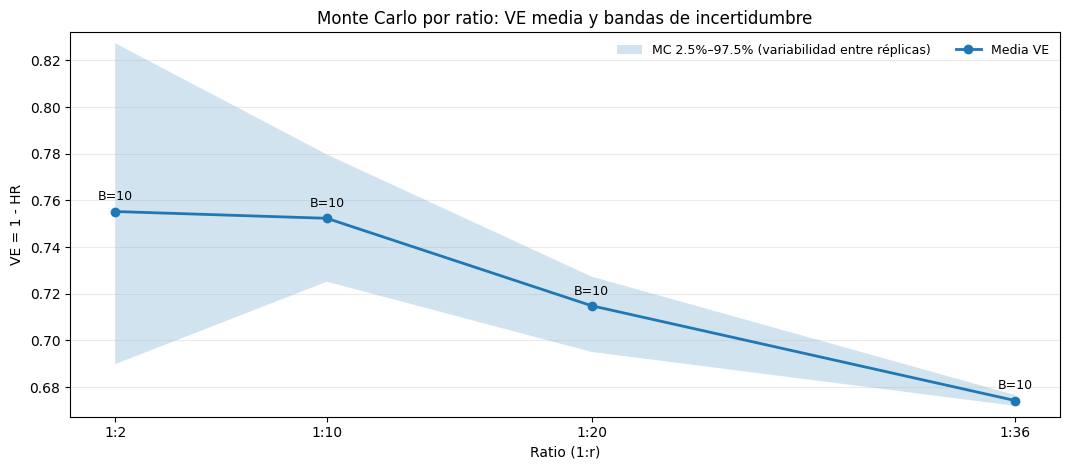

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# df_summary viene del bloque anterior y tiene:
# ratio, B, achieved_ratio, VE_mean, VE_se_mean, VE_q025, VE_q975

def plot_df_summary(df_summary, use_achieved_ratio=False):
    dfp = df_summary.copy().sort_values("ratio")

    x = dfp["achieved_ratio"].values if use_achieved_ratio else dfp["ratio"].values
    xlabels = [f"1:{int(r)}" for r in dfp["ratio"].values]  # siempre mostrar 1:r
    y = dfp["VE_mean"].values

    # Banda por percentiles MC
    lo_mc = dfp["VE_q025"].values
    hi_mc = dfp["VE_q975"].values

    # IC normal para la MEDIA (mean ± 1.96*SE_mean)
    z = 1.959963984540054
    lo_mean = y - z * dfp["VE_se_mean"].values
    hi_mean = y + z * dfp["VE_se_mean"].values

    fig, ax = plt.subplots(figsize=(10.8, 4.8))

    # Banda MC (2.5%–97.5%)
    ax.fill_between(x, lo_mc, hi_mc, alpha=0.20, label="MC 2.5%–97.5% (variabilidad entre réplicas)")

    # Banda para la media (IC normal de la media)
    # ax.fill_between(x, lo_mean, hi_mean, alpha=0.20, label="IC 95% de la media (normal)")

    # Línea de la media
    ax.plot(x, y, marker="o", linewidth=2, label="Media VE")

    # Etiquetas sobre puntos (opcional pero útil)
    for xi, yi, bi in zip(x, y, dfp["B"].values):
        ax.annotate(f"B={int(bi)}", (xi, yi), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=9)

    ax.set_xlabel("Ratio (1:r)" if not use_achieved_ratio else "Achieved ratio (n_imm_sample / n_no)")
    ax.set_ylabel("VE = 1 - HR")
    ax.set_title("Monte Carlo por ratio: VE media y bandas de incertidumbre")
    ax.grid(axis="y", alpha=0.25)

    # Formatear eje x con 1:r
    if not use_achieved_ratio:
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)

    # Mejorar límites y leyenda
    y_min = np.nanmin([lo_mc.min(), lo_mean.min(), y.min()])
    y_max = np.nanmax([hi_mc.max(), hi_mean.max(), y.max()])
    pad = 0.03 * (y_max - y_min) if np.isfinite(y_max - y_min) and (y_max - y_min) > 0 else 0.02
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.legend(ncol=2, frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

# --- uso ---
plot_df_summary(df_summary, use_achieved_ratio=False)
# si quieres ver el eje x como ratio logrado (cuando hay cap por falta de inmunes):
# plot_df_summary(df_summary, use_achieved_ratio=True)


In [ ]:
########################################################## ESTO ES LITERALMENTE CREAR NO INMUNES SAMPLEANDO CON REEMPLAZO DE LOS QUE YA HAY.

ID_COL = "RUN"
IMM_BASE_COL = "inmunizado"   # en df_base
N_EXTRA = 3480
SEED = 123

covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
strata = ['region','mes_nac_name','SEMANAS','semana_nac']

df_base = df_f_vrs_mrz_ag.copy()      # 1 fila por RUN
df_tv   = df_cox_vrs_mrz_ag.copy()    # time-varying

# IDs no-inmunes elegibles para clonar (desde base flat)
no_ids = (
    df_base.loc[df_base[IMM_BASE_COL] == 0, ID_COL]
    .dropna()
    .astype(str)
    .unique()
)

# Asegurar dtype para el merge
df_tv = df_tv.copy()
df_tv[ID_COL] = df_tv[ID_COL].astype(str)

def one_run(seed, n_extra=N_EXTRA):
    rng = np.random.default_rng(seed)

    picked = rng.choice(no_ids, size=n_extra, replace=True)
    new_ids = np.array([f"SIMNO_{seed}_{i:06d}" for i in range(n_extra)], dtype=object)
    map_df = pd.DataFrame({"orig_id": picked, "new_id": new_ids})

    tv_subset = df_tv[df_tv[ID_COL].isin(map_df["orig_id"])].copy()

    df_clones = (
        tv_subset.merge(map_df, left_on=ID_COL, right_on="orig_id", how="inner")
                 .drop(columns=["orig_id", ID_COL])
                 .rename(columns={"new_id": ID_COL})
    )

    # Alinear columnas
    df_clones = df_clones.reindex(columns=df_tv.columns, fill_value=np.nan)

    df_aug = pd.concat([df_tv, df_clones], ignore_index=True)

    ctv = CoxTimeVaryingFitter()
    # robust=True suele ser recomendable si está disponible en tu versión
    ctv.fit(
        df_aug[covs],
        id_col=ID_COL,
        event_col="event_vrs",
        start_col="start",
        stop_col="stop",
        strata=strata,
        # robust=True,   # descomenta si tu lifelines lo soporta
    )

    summ = printSummary(ctv)  # tu helper
    ve   = float(summ.effectiveness.loc["inmunizado"])
    lo   = float(summ.eff_lower_95.loc["inmunizado"])
    hi   = float(summ.eff_upper_95.loc["inmunizado"])
    return ve, lo, hi

# =========================
# Monte Carlo
# =========================
B = 300  # prueba 50 primero si es pesado
results = []
fail = 0

for b in range(B):
    seed = SEED + b
    try:
        ve, lo, hi = one_run(seed)
        results.append({"iter": b, "seed": seed, "VE": ve, "VE_lo95": lo, "VE_hi95": hi})
    except Exception as e:
        fail += 1
        results.append({"iter": b, "seed": seed, "VE": np.nan, "VE_lo95": np.nan, "VE_hi95": np.nan, "error": str(e)})

df_mc = pd.DataFrame(results)

print("OK:", df_mc["VE"].notna().sum(), "| Fail:", fail)
df_mc.head()


OK: 300 | Fail: 0


,iter,seed,VE,VE_lo95,VE_hi95
0,0,123,0.741994,0.694689,0.781970
1,1,124,0.735821,0.687514,0.776660
2,2,125,0.730301,0.680356,0.772443
3,3,126,0.736009,0.687294,0.777135
4,4,127,0.717583,0.663969,0.762642


In [65]:
df_mc.to_csv(path_data/'df_montecarlo_eff_triplicar_noinmu.csv')

n MC = 300
Median(VE)     = 0.7362  [p2.5=0.7093, p97.5=0.7591]
Median(lower)  = 0.6875   [p2.5=0.6542, p97.5=0.7156]
Median(upper)  = 0.7773   [p2.5=0.7557, p97.5=0.7960]


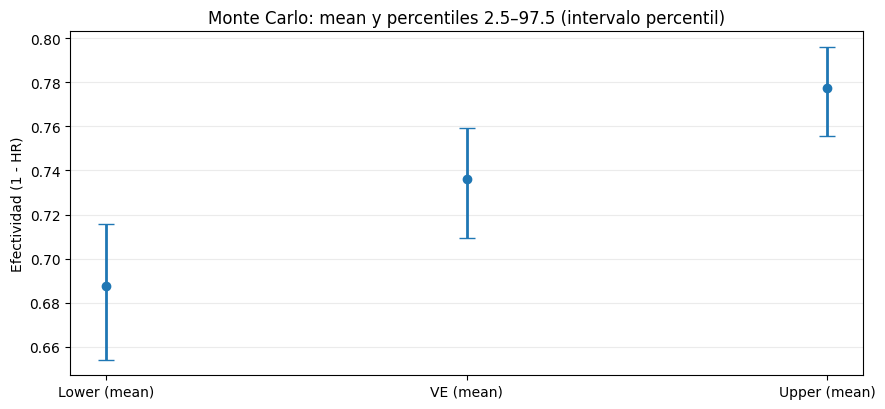

In [ ]:
######################################################################################### MARCEL: EL GRÁFICO
ok = df_mc.dropna(subset=["VE", "VE_lo95", "VE_hi95"]).copy()

def mc_percentile_ci(x, alpha=0.05):
    """
    Intervalo percentil para la DISTRIBUCIÓN de x:
    [q(alpha/2), q(1-alpha/2)], y además devuelve la mediana (o media si prefieres).
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan, 0
    lo = np.quantile(x, alpha/2)
    hi = np.quantile(x, 1 - alpha/2)
    med = np.quantile(x, 0.5)     # típico: mediana (más robusta)
    return med, lo, hi, x.size

def mean_with_percentile_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan, 0
    m = x.mean()
    lo = np.quantile(x, alpha/2)
    hi = np.quantile(x, 1-alpha/2)
    return m, lo, hi, x.size

# Puedes usar mediana (recomendado) o media (si prefieres):
# m_ve, lo_ve, hi_ve, n = mc_percentile_ci(ok["VE"])
# m_l,  lo_l,  hi_l,  _ = mc_percentile_ci(ok["VE_lo95"])
# m_u,  lo_u,  hi_u,  _ = mc_percentile_ci(ok["VE_hi95"])

m_ve, lo_ve, hi_ve, n = mean_with_percentile_ci(ok["VE"])
m_l,  lo_l,  hi_l,  _ = mean_with_percentile_ci(ok["VE_lo95"])
m_u,  lo_u,  hi_u,  _ = mean_with_percentile_ci(ok["VE_hi95"])

print(f"n MC = {n}")
print(f"Median(VE)     = {m_ve:.4f}  [p2.5={lo_ve:.4f}, p97.5={hi_ve:.4f}]")
print(f"Median(lower)  = {m_l:.4f}   [p2.5={lo_l:.4f}, p97.5={hi_l:.4f}]")
print(f"Median(upper)  = {m_u:.4f}   [p2.5={lo_u:.4f}, p97.5={hi_u:.4f}]")

labels = ["Lower (mean)", "VE (mean)", "Upper (mean)"]
y = np.array([m_l, m_ve, m_u])
yerr = np.array([
    [m_l - lo_l,   m_ve - lo_ve,   m_u - lo_u],
    [hi_l - m_l,   hi_ve - m_ve,   hi_u - m_u],
])

x = np.arange(3)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=6, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Efectividad (1 - HR)")
ax.set_title("Monte Carlo: mean y percentiles 2.5–97.5 (intervalo percentil)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()




In [93]:
############################################################################################ quiero intentar usar stabilized weights

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


def build_stabilized_weights_tv(
    df_tv,
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    status_col="inmunizado",     # 0/1 status por intervalo
    covs=None,                   # covariables para pi_ij (NO incluir status_col)
    time_col_name="week",        # nombre de la variable tiempo discreto
    time_from="start",           # "start" o "stop" para asignar semana
    clip_pi=(1e-3, 1-1e-3),      # recorte de pi para evitar infinitos
    truncate_w=(0.01, 0.99),     # truncamiento percentil (opcional) para estabilidad
    seed=123,
):
    """
    Construye stabilized weights (SW) para inicio de tratamiento (0->1) en datos time-varying.
    Devuelve df_tv con columnas:
      - A: indicador de inicio en el intervalo
      - pi: P(A=1|X) entre los elegibles (no tratados al inicio)
      - p: prob marginal por semana
      - sw_step: factor por intervalo
      - sw: peso acumulado por sujeto (producto)
    """
    if covs is None:
        covs = ["sexo", "region", "mes_nac_name", "SEMANAS", "semana_nac"]

    df = df_tv.copy()

    # 1) Ordenar y crear semana discreta
    df[start_col] = pd.to_numeric(df[start_col], errors="coerce")
    df[stop_col]  = pd.to_numeric(df[stop_col], errors="coerce")

    df = df.sort_values([id_col, start_col]).reset_index(drop=True)

    base_time = df[start_col] if time_from == "start" else df[stop_col]
    # Si start/stop están en días:
    df[time_col_name] = (base_time // 7).astype(int)

    # 2) Detectar "inicio" 0->1
    prev = df.groupby(id_col)[status_col].shift(1)
    prev = prev.fillna(0).astype(int)

    df["_prev_status"] = prev
    # Elegible para iniciar: no inmunizado al inicio del intervalo
    df["_eligible"] = (df["_prev_status"] == 0)

    # Inicio en el intervalo = pasa a status 1 desde 0
    df["A"] = ((df["_eligible"]) & (df[status_col] == 1)).astype(int)

    # 3) Construir dataset para modelo pi_ij: SOLO intervalos elegibles (aún no tratados)
    elig = df[df["_eligible"]].copy()

    # Si hay semanas sin variación, el modelo puede sufrir. Igual lo regularizamos.
    # Incluimos tiempo (week) como covariable (categoría) para capturar campaña temporal.
    model_features = covs + [time_col_name]

    # separar numéricas vs categóricas
    Xtmp = elig[model_features].copy()
    num_cols = [c for c in model_features if pd.api.types.is_numeric_dtype(Xtmp[c])]
    cat_cols = [c for c in model_features if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )

    clf = LogisticRegression(
        max_iter=4000,
        solver="lbfgs",
        n_jobs=-1,
    )

    pipe = Pipeline([("pre", pre), ("clf", clf)])

    y = elig["A"].astype(int).values
    pipe.fit(Xtmp, y)

    # 4) Predecir pi_ij para elegibles
    pi = pipe.predict_proba(Xtmp)[:, 1]
    lo, hi = clip_pi
    pi = np.clip(pi, lo, hi)

    elig["pi"] = pi

    # 5) p_j marginal por semana (entre elegibles)
    # p_j = P(A=1 | en riesgo de iniciar en semana j)
    p_by_week = elig.groupby(time_col_name)["A"].mean()
    # recortar también para estabilidad
    p_by_week = p_by_week.clip(lo, hi)
    elig["p"] = elig[time_col_name].map(p_by_week).astype(float)

    # 6) sw_step: p/pi si inicia, (1-p)/(1-pi) si no inicia
    elig["sw_step"] = np.where(
        elig["A"].eq(1),
        elig["p"] / elig["pi"],
        (1 - elig["p"]) / (1 - elig["pi"]),
    )

    # 7) Volver a df completo: para no-elegibles (ya tratados), factor = 1
    df = df.merge(
        elig[[id_col, start_col, stop_col, "pi", "p", "sw_step"]],
        on=[id_col, start_col, stop_col],
        how="left",
        validate="one_to_one",
    )
    df["sw_step"] = df["sw_step"].fillna(1.0)
    df["pi"] = df["pi"].astype(float)
    df["p"]  = df["p"].astype(float)

    # 8) Peso acumulado por sujeto = producto por intervalos
    df["sw"] = df.groupby(id_col)["sw_step"].cumprod()

    # 9) Truncamiento de pesos (recomendado en práctica)
    if truncate_w is not None:
        ql, qh = truncate_w
        w_lo, w_hi = df["sw"].quantile([ql, qh]).values
        df["sw_trunc"] = df["sw"].clip(w_lo, w_hi)
    else:
        df["sw_trunc"] = df["sw"]

    # outputs útiles
    info = {
        "n_rows": len(df),
        "n_ids": df[id_col].nunique(),
        "n_eligible_rows": int(df["_eligible"].sum()),
        "n_initiations": int(df["A"].sum()),
        "w_trunc_lo_hi": tuple(df["sw_trunc"].quantile([0.01, 0.99]).values),
    }

    return df, pipe, p_by_week, info


In [98]:
from lifelines import CoxTimeVaryingFitter

covs_pi = ["prematuro", "region", "semana_nac",'eleg_2025']  # lo que dijiste + semana_nac

df_sw, ps_model, p_by_week, info = build_stabilized_weights_tv(
    df_tv = df_cox_vrs_mrz_ag,
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    status_col="inmunizado",
    covs=covs_pi,
    time_col_name="week",
    time_from="start",
    clip_pi=(1e-3, 1-1e-3),
    truncate_w=(0.01, 0.99),   # recomendado
)

print(info)
print("Peso sw_trunc: min/mean/max =", df_sw["sw_trunc"].min(), df_sw["sw_trunc"].mean(), df_sw["sw_trunc"].max())

# Cox TV con pesos estabilizados
ctv = CoxTimeVaryingFitter()
strata = ["region","mes_nac_name","SEMANAS","semana_nac"]  # lo tuyo

covs_fit = [
    "start","stop","event_vrs","RUN",
    "inmunizado",   # efecto de status
    "sexo","region","mes_nac_name","SEMANAS","semana_nac",
    "sw_trunc"
]

ctv.fit(
    df_sw[covs_fit],
    id_col="RUN",
    event_col="event_vrs",
    start_col="start",
    stop_col="stop",
    strata=strata,
    weights_col="sw_trunc",
)

display(printSummary(ctv))


{'n_rows': 200629, 'n_ids': 115061, 'n_eligible_rows': 200629, 'n_initiations': 111976, 'w_trunc_lo_hi': (0.3020724223195189, 2.8071722813999287)}
Peso sw_trunc: min/mean/max = 0.3020724223195189 1.3751827014584148 2.8071722813999287


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.199334,0.698605,0.095203,-1.385929,-1.012739,0.636777,0.749909,0.0
sexo,0.501355,-0.650957,0.052272,0.398904,0.603807,-0.829069,-0.490190,0.0


In [103]:
from lifelines import CoxTimeVaryingFitter

covs = ['start','stop','event_vrs','inmunizado','RUN','sexo','region','mes_nac_name','SEMANAS','semana_nac','sw_trunc']
ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_w[covs],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=['region','mes_nac_name','SEMANAS','semana_nac'],
    weights_col="sw_trunc",
)
display(printSummary(ctv))


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.113269,0.671517,0.113759,-1.336233,-0.890305,0.589470,0.737166,0.0
sexo,0.519115,-0.680540,0.061140,0.399282,0.638948,-0.894487,-0.490754,0.0


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.117552,0.672921,0.114999,-1.342947,-0.892158,0.590229,0.738925,0.0
sexo,0.519326,-0.680894,0.061173,0.399428,0.639224,-0.895009,-0.490972,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


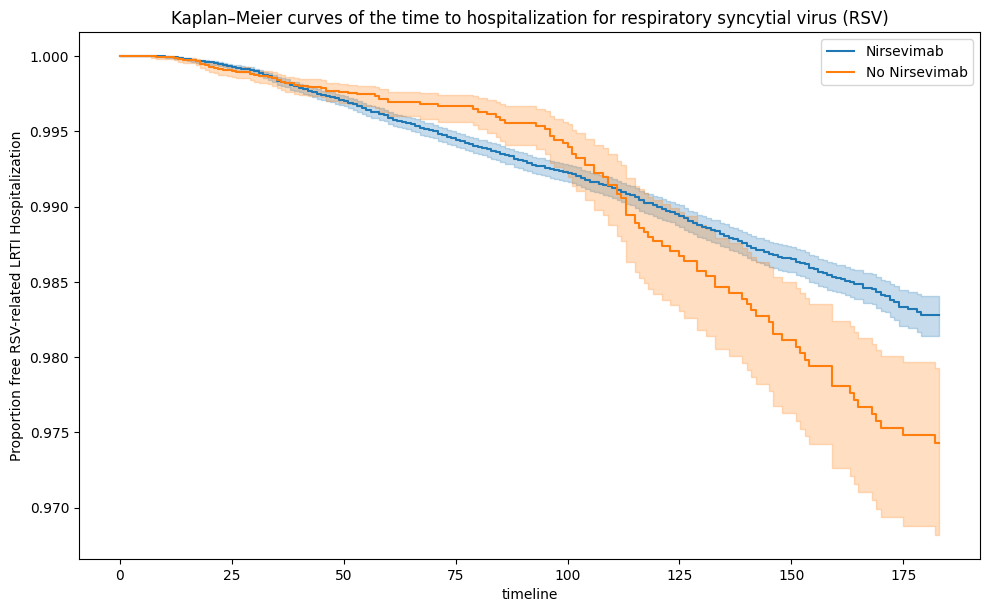

In [200]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_mrz_ag.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))
df_mayer_vrs_agg_mz_ag, df_mayer_vrs_mz_ag = plot_extended_kaplan_meier(df_cox_vrs_mrz_ag)

#### matching

In [ ]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

df_tv = df_cox_vrs_mrz_ag.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['semana_nac','SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:2",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))



1:2 ['1', '2']
here aaa
Total cases = 3085, Total controls = 111976
Total cases matched is : 2996, Total control matched is : 5992
ratio: 1:2
No matched : 89
Iteration 1: norm_delta = 7.42e-01, step_size = 0.9500, log_lik = -192.54483, newton_decrement = 4.25e+01, seconds_since_start = 2.2
Iteration 2: norm_delta = 3.17e-02, step_size = 0.9500, log_lik = -151.50853, newton_decrement = 6.75e-02, seconds_since_start = 4.5
Iteration 3: norm_delta = 2.05e-03, step_size = 0.9500, log_lik = -151.44063, newton_decrement = 2.74e-04, seconds_since_start = 6.7
Iteration 4: norm_delta = 1.10e-04, step_size = 1.0000, log_lik = -151.44036, newton_decrement = 7.09e-07, seconds_since_start = 8.9
Iteration 5: norm_delta = 5.38e-09, step_size = 1.0000, log_lik = -151.44036, newton_decrement = 1.71e-15, seconds_since_start = 11.2
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.57196,0.792362,0.186673,-1.937832,-1.206089,0.700634,0.855984,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


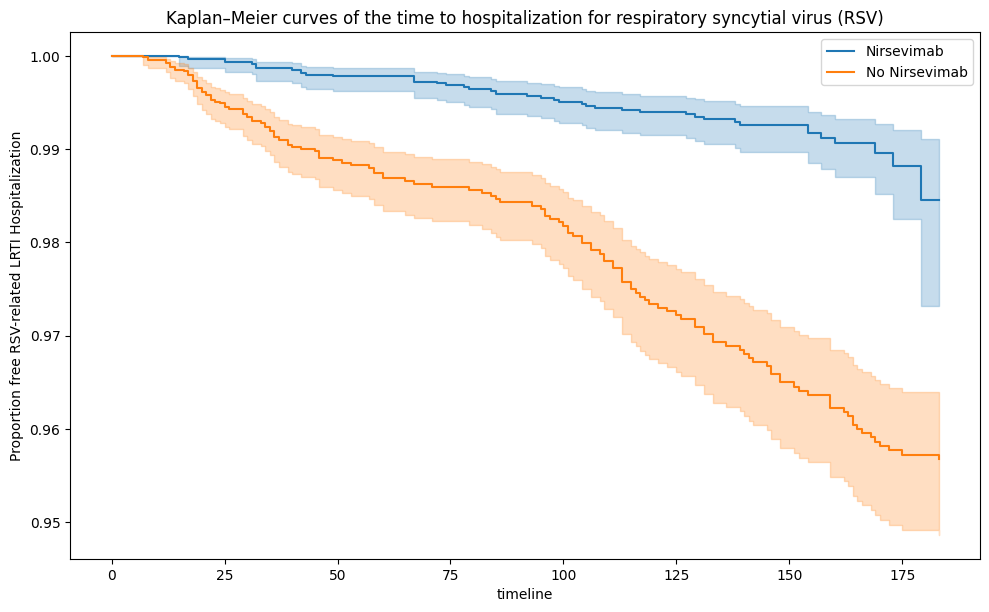

In [39]:
df_mayer_vrs_match, df_mayer_vrs_match = plot_extended_kaplan_meier(df_tv_matched)

FULL ANALISIS MATCHING ABAJO

REPLICAR MATCH 2024

In [136]:
df_cox_vrs_24, _, df_f_vrs_24, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        T_inicial = pd.to_datetime('2024-04-01'),
                                                        fecha_dt = pd.to_datetime('2024-09-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1490
ruts perdidos por filtro semanas y peso:  519
Droped intersex: 22
Datos perdidos por edad madre atípica: 210
Datos perdidos por fecha ingreso menor a fecha nacimiento: 19
vrs en los primeros 7 dias d

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.555370,0.788889,0.080961,-1.714051,-1.396689,0.752585,0.819865,0.0
sexo,0.473502,-0.605608,0.059846,0.356206,0.590799,-0.805430,-0.427902,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


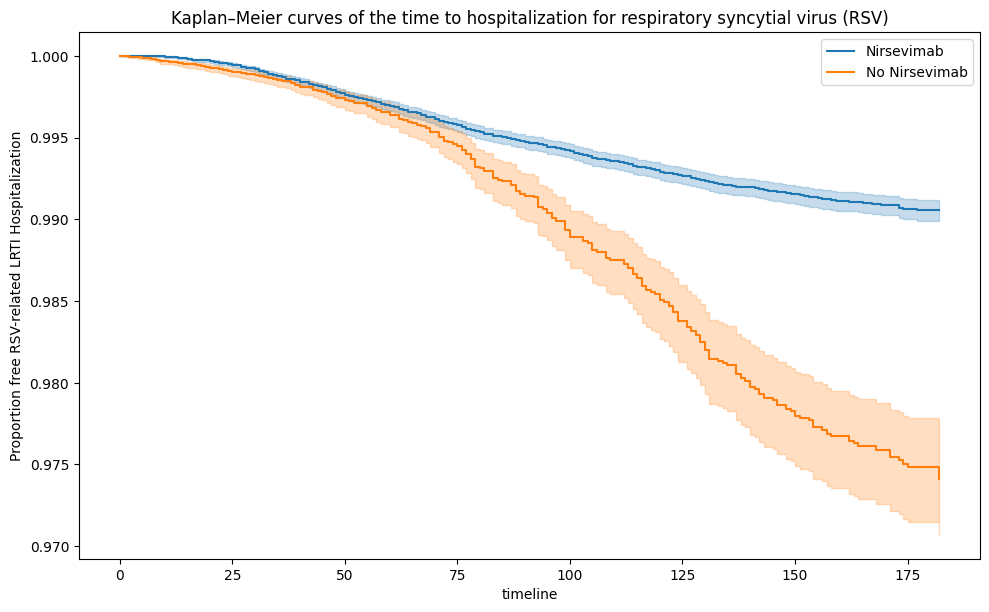

In [202]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_24.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))
df_mayer_vrs_agg_24, df_mayer_vrs_24 = plot_extended_kaplan_meier(df_cox_vrs_24)

In [203]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

df_tv = df_cox_vrs_24.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['semana_nac','SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:2",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:2 ['1', '2']
here aaa
Total cases = 8494, Total controls = 144839
Total cases matched is : 7566, Total control matched is : 15132
ratio: 1:2
No matched : 928
Iteration 1: norm_delta = 7.74e-01, step_size = 0.9500, log_lik = -398.27301, newton_decrement = 1.00e+02, seconds_since_start = 5.8
Iteration 2: norm_delta = 2.94e-02, step_size = 0.9500, log_lik = -302.11018, newton_decrement = 1.24e-01, seconds_since_start = 12.7
Iteration 3: norm_delta = 1.88e-03, step_size = 0.9500, log_lik = -301.98534, newton_decrement = 4.98e-04, seconds_since_start = 19.5
Iteration 4: norm_delta = 1.01e-04, step_size = 1.0000, log_lik = -301.98484, newton_decrement = 1.29e-06, seconds_since_start = 25.8
Iteration 5: norm_delta = 4.79e-09, step_size = 1.0000, log_lik = -301.98484, newton_decrement = 2.90e-15, seconds_since_start = 32.2
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.636322,0.805305,0.127815,-1.886835,-1.38581,0.749879,0.848449,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


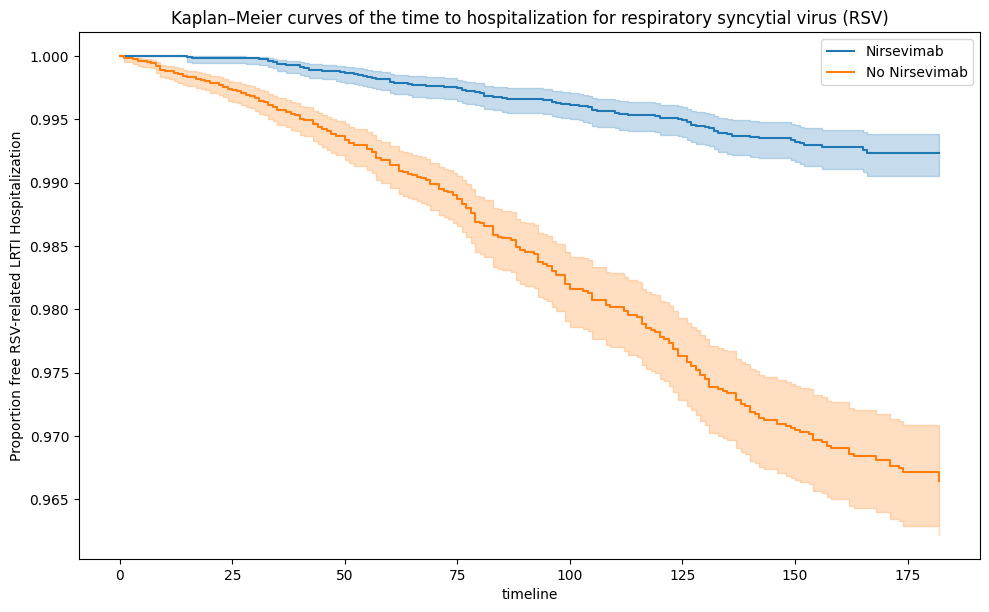

In [41]:
df_mayer_vrs_match, df_mayer_vrs_match = plot_extended_kaplan_meier(df_tv_matched)